In [1]:
# imports
import pandas as pd
import ast
from pathlib import Path
import json
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# consistent visual style for all plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 100, 'axes.titlesize': 13})

In [2]:
project_root = Path.cwd()
default_data_dir = project_root / "data"

env_data_dir = os.getenv("DATA_DIR")
local_cfg_path = project_root / "paths.local.json"

if env_data_dir:
	data_dir = Path(env_data_dir).expanduser()
elif local_cfg_path.exists():
	data_dir = Path(json.loads(local_cfg_path.read_text())["data_dir"]).expanduser()
else:
	data_dir = default_data_dir

csv_path = data_dir / "sample_data.csv"
print("Using data directory:", data_dir)

Using data directory: /Users/vitto/Desktop/SP26/DA/project_2/15_Veterinarian_Recommendation


In [3]:
meta_path = data_dir / "meta_Pet_supplies.json"
ratings_path = data_dir / "ratings_Pet_supplies.csv"

In [4]:
meta_data = []

# with open("pet_supplies.json", "r") as f:
with open(meta_path, "r") as f:
    for line in f:
        meta_data.append(ast.literal_eval(line))

meta_df = pd.DataFrame(meta_data)

In [5]:
meta_df.head(10)

,asin,related,title,price,salesRank,imUrl,brand,categories,description
0,0615553605,"{'also_bought': ['0836269195', '1931993807', '...",Pet Qwerks Treat Cookbook with Cutters,10.95,{'Pet Supplies': 34134},http://ecx.images-amazon.com/images/I/41yroPoJ...,Pet Qwerks,"[[Pet Supplies, Dogs, Toys]]",Know exactly what your dog is eating with 101 ...
1,0615583474,"{'also_viewed': ['1937406679', '1936319284', '...",It's A Cat's Life,NaN,{'Pet Supplies': 452691},http://ecx.images-amazon.com/images/I/51%2BBp0...,NaN,[[Pet Supplies]],"An Interactive Cat Book, by Howie ""The World's..."
2,0972585419,"{'also_bought': ['B0002FP328', 'B0002FP32I', '...",Feathered Phonics The Easy Way To Teach Your B...,0.92,{'Pet Supplies': 21104},http://ecx.images-amazon.com/images/I/61tAtKN0...,Pet Media,"[[Pet Supplies, Pet Supplies: International Sh...",Volume 1: 96 Words & Phrases! This is the CD t...
3,0975412809,"{'also_bought': ['0345476263', 'B001I0BNOI', '...",Notes From The Grooming Table by Melissa Verplank,59.95,{'Pet Supplies': 1960},http://ecx.images-amazon.com/images/I/615swQkX...,Melissa Verplank,"[[Pet Supplies, Small Animals, Grooming]]","A quality, how-to grooming book that is an exc..."
4,0975412868,"{'also_bought': ['0975412809', '0345476263', '...",Theory of Five Book by Melissa Verplank,NaN,{'Pet Supplies': 70355},http://ecx.images-amazon.com/images/I/51xpkAJ8...,NaN,"[[Pet Supplies, Small Animals, Grooming]]",This book simplifies the grooming process by o...
5,0977264815,NaN,ABC's of Behavior Shaping; Proactive Behavior ...,NaN,{'Pet Supplies': 206215},http://ecx.images-amazon.com/images/I/51vwGj9q...,NaN,[[Pet Supplies]],Ted Turner's two classic seminars now availabl...
6,0979137802,NaN,Antique Christmas Memories,NaN,{'Pet Supplies': 399005},http://ecx.images-amazon.com/images/I/31hyI2rh...,NaN,[[Pet Supplies]],NaN
7,0979699967,NaN,Simply Charming Circles,1.45,{'Pet Supplies': 157918},http://ecx.images-amazon.com/images/I/31QvzPLV...,,[[Pet Supplies]],NaN
8,0982393555,"{'also_viewed': ['B00701NED2', 'B006HO8URI', '...",Pill Wrap Paste - 56 servings,NaN,{'Pet Supplies': 132242},http://ecx.images-amazon.com/images/I/4178yl5C...,NaN,[[Pet Supplies]],NaN
9,0983794812,"{'also_viewed': ['0821256971', '0983794804', '...","Pathway Cat Journal, Capture Your Memories, Pe...",24.33,{'Pet Supplies': 146463},http://ecx.images-amazon.com/images/I/511SAprc...,NaN,"[[Pet Supplies, Cats, Memorials]]","Kitty capers, playful antics and quality cuddl..."


In [6]:
meta_df.columns

Index(['asin', 'related', 'title', 'price', 'salesRank', 'imUrl', 'brand',
       'categories', 'description'],
      dtype='str')

In [7]:
# print the contents of the README file for reference
readme_path = data_dir / "README.txt"
with open(readme_path, "r") as f:
    readme_content = f.read()
print(readme_content)

* This dataset include (user,item,rating,timestamp) tuples
* Metadata includes descriptions, price, sales-rank, brand info, and co-purchasing links, where:

 * asin - ID of the product, e.g. 0000031852
 * title - name of the product
 * price - price in US dollars (at time of crawl)
 * imUrl - url of the product image
 * related - related products (also bought, also viewed, bought together, buy after viewing)
 * salesRank - sales rank information
 * brand - brand name
 * categories - list of categories the product belongs to



In [8]:
meta_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 110707 entries, 0 to 110706
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   asin         110707 non-null  str    
 1   related      82912 non-null   object 
 2   title        110499 non-null  str    
 3   price        82458 non-null   float64
 4   salesRank    108454 non-null  object 
 5   imUrl        110610 non-null  str    
 6   brand        49366 non-null   str    
 7   categories   110707 non-null  object 
 8   description  104815 non-null  str    
dtypes: float64(1), object(3), str(5)
memory usage: 7.6+ MB


In [9]:
ratings_df = pd.read_csv(
    ratings_path,
    header=None,
    names=["user_id", "asin", "rating", "timestamp"] # asin is the product id
)
ratings_df.head(10)

,user_id,asin,rating,timestamp
0,A3PG0KS1YE8MR4,0615553605,5.0,1354838400
1,A363P047LR5XI6,0615553605,4.0,1373932800
2,ABZ8CQXD42H4,0615553605,1.0,1386028800
3,A3J8QW1MV1OP01,0615583474,5.0,1347321600
4,A3ISA8Z0NB0ILH,0615583474,5.0,1358899200
5,A2A8F5QRQOAWVS,0615583474,5.0,1371513600
6,A3FH308L8K5Q9M,0615583474,5.0,1358640000
7,A2BD1HQS031I6U,0615583474,5.0,1359676800
8,AK5D5XJ7OHNFG,0615583474,5.0,1358640000
9,A2H6BM7IZI4U6K,0615583474,5.0,1359244800


In [10]:
ratings_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1235316 entries, 0 to 1235315
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   user_id    1235316 non-null  str    
 1   asin       1235316 non-null  str    
 2   rating     1235316 non-null  float64
 3   timestamp  1235316 non-null  int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 37.7 MB


# Data Exploration

## Ratings dataset

### Some statistics

In [11]:
print(f"Ratings dataset shape: {ratings_df.shape}")
print(f"Unique users  : {ratings_df['user_id'].nunique():,}")
print(f"Unique items  : {ratings_df['asin'].nunique():,}")
print(f"Missing values: {ratings_df.isnull().sum().to_dict()}")
print()
ratings_df['rating'].describe()

Ratings dataset shape: (1235316, 4)
Unique users  : 740,985
Unique items  : 103,288
Missing values: {'user_id': 0, 'asin': 0, 'rating': 0, 'timestamp': 0}



count    1.235316e+06
mean     4.110714e+00
std      1.331676e+00
min      1.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

### Distribution

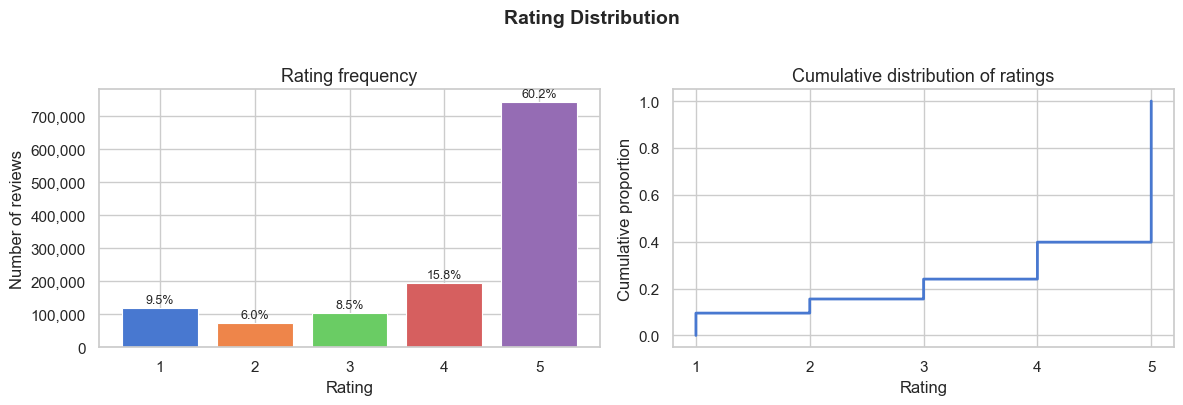


Key statistics:
  Mean rating  : 4.111
  Median rating: 5.0
  Std deviation: 1.332
  % of 5-star  : 60.2%
  % of 1-star  : 9.5%


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Count bar chart ---
rating_counts = ratings_df['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index.astype(int), rating_counts.values,
            color=sns.color_palette('muted', 5), edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Number of reviews')
axes[0].set_title('Rating frequency')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{int(x):,}'))
for bar, count in zip(axes[0].patches, rating_counts.values):
    pct = count / len(ratings_df) * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(ratings_df)*0.005,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

# --- Cumulative distribution ---
sorted_ratings = np.sort(ratings_df['rating'].values)
cdf = np.arange(1, len(sorted_ratings)+1) / len(sorted_ratings)
axes[1].step(sorted_ratings, cdf, where='post', linewidth=2)
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Cumulative proportion')
axes[1].set_title('Cumulative distribution of ratings')
axes[1].set_xticks([1, 2, 3, 4, 5])

fig.suptitle('Rating Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nKey statistics:")
print(f"  Mean rating  : {ratings_df['rating'].mean():.3f}")
print(f"  Median rating: {ratings_df['rating'].median():.1f}")
print(f"  Std deviation: {ratings_df['rating'].std():.3f}")
print(f"  % of 5-star  : {(ratings_df['rating'] == 5).mean()*100:.1f}%")
print(f"  % of 1-star  : {(ratings_df['rating'] == 1).mean()*100:.1f}%")

#### Observation
The rating distribution is very skewed, with the vast majority of reviews being 5 stars. Roughly 60% of reviews are 5 stars, with the remaining 40% distributed across 1-4 stars. 

In [13]:
# TODO: Could be interesting to plot review activity over time

### Review per user and item (sparsity)

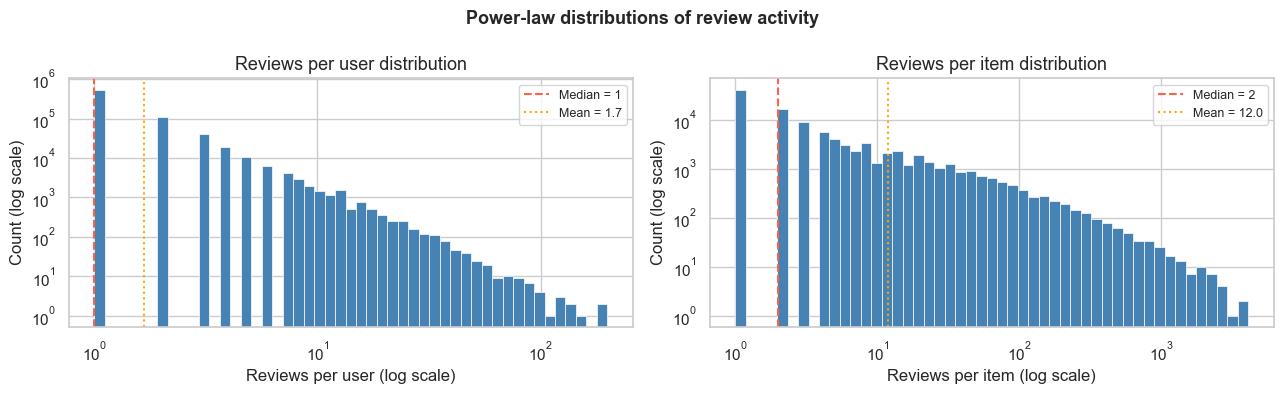

Users   : 740,985  |  median reviews/user: 1  |  max: 199
Items   : 103,288  |  median reviews/item: 2  |  max: 4109
Matrix sparsity: 99.9984%
Users with only 1 review: 538,197 (72.6%)


In [14]:
reviews_per_user = ratings_df.groupby('user_id')['rating'].count()
reviews_per_item = ratings_df.groupby('asin')['rating'].count()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, series, label in zip(
    axes,
    [reviews_per_user, reviews_per_item],
    ['Reviews per user', 'Reviews per item']
):
    # Use log-scale bins for a power-law distribution
    bins = np.logspace(0, np.log10(series.max()), 50)
    ax.hist(series, bins=bins, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(label + ' (log scale)')
    ax.set_ylabel('Count (log scale)')
    ax.set_title(f'{label} distribution')
    ax.axvline(series.median(), color='tomato', linestyle='--',
               linewidth=1.5, label=f'Median = {series.median():.0f}')
    ax.axvline(series.mean(), color='orange', linestyle=':',
               linewidth=1.5, label=f'Mean = {series.mean():.1f}')
    ax.legend(fontsize=9)

plt.suptitle('Power-law distributions of review activity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

n_users = reviews_per_user.shape[0]
n_items = reviews_per_item.shape[0]
sparsity = 1 - len(ratings_df) / (n_users * n_items)
print(f"Users   : {n_users:,}  |  median reviews/user: {reviews_per_user.median():.0f}  |  max: {reviews_per_user.max()}")
print(f"Items   : {n_items:,}  |  median reviews/item: {reviews_per_item.median():.0f}  |  max: {reviews_per_item.max()}")
print(f"Matrix sparsity: {sparsity*100:.4f}%")
print(f"Users with only 1 review: {(reviews_per_user == 1).sum():,} ({(reviews_per_user == 1).mean()*100:.1f}%)")

#### Observation
The data is very sparse. Most users have reviewed only one or two items, and most products have very few reviews associated with them.

## Metadata dataset

### Statistics


In [15]:
print(f"Metadata dataset shape: {meta_df.shape}")
print()

# Missing value summary
missing = meta_df.isnull().sum()
missing_pct = (missing / len(meta_df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print("Missing values per column:")
print(missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_%', ascending=False))
print()

# Numeric summary (price)
print("Price statistics:")
print(meta_df['price'].describe())

Metadata dataset shape: (110707, 9)

Missing values per column:
             missing_count  missing_%
brand                61341      55.41
price                28249      25.52
related              27795      25.11
description           5892       5.32
salesRank             2253       2.04
title                  208       0.19
imUrl                   97       0.09

Price statistics:
count    82458.000000
mean        29.833480
std         49.305825
min          0.010000
25%          8.990000
50%         15.480000
75%         30.390000
max        998.990000
Name: price, dtype: float64


### Missing values

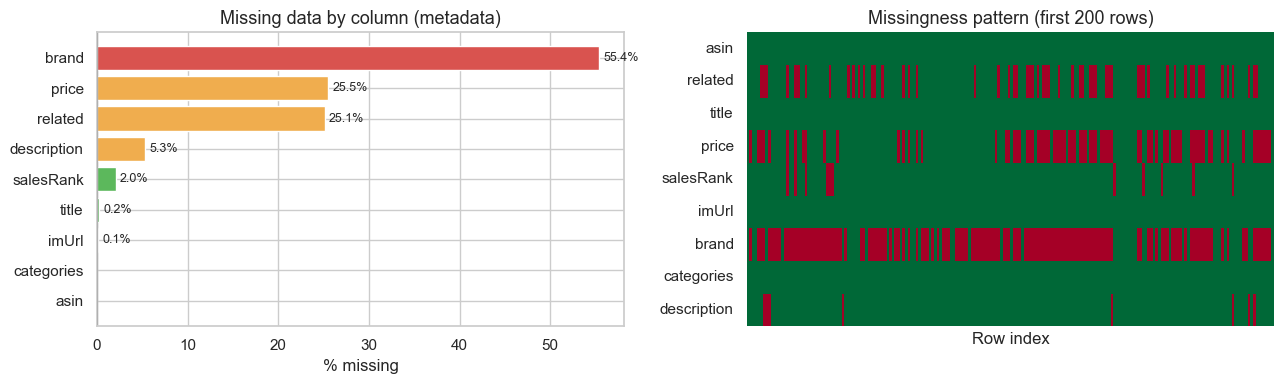

In [16]:
# TODO: use a heatmap to show missingness patterns

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Bar chart of % missing ---
missing_pct_sorted = (meta_df.isnull().mean() * 100).sort_values(ascending=True)
colors = ['#d9534f' if v > 30 else '#f0ad4e' if v > 5 else '#5cb85c'
          for v in missing_pct_sorted.values]
axes[0].barh(missing_pct_sorted.index, missing_pct_sorted.values, color=colors)
axes[0].set_xlabel('% missing')
axes[0].set_title('Missing data by column (metadata)')
axes[0].axvline(0, color='black', linewidth=0.8)
for i, (col, val) in enumerate(missing_pct_sorted.items()):
    if val > 0:
        axes[0].text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9)

# --- Missingness pattern on a sample (first 200 rows) ---
sample = meta_df.head(200).isnull().astype(int)
sns.heatmap(sample.T, ax=axes[1], cmap='RdYlGn_r', cbar=False,
            linewidths=0, xticklabels=False)
axes[1].set_title('Missingness pattern (first 200 rows)')
axes[1].set_xlabel('Row index')

plt.tight_layout()
plt.show()

#### Observation
More than 50% of products are missing the brand, which is concerning. Price and the 'related' category are missing for one in every four entries, though the latter might not be a deal-breaker for our purposes. 

### Price distribution

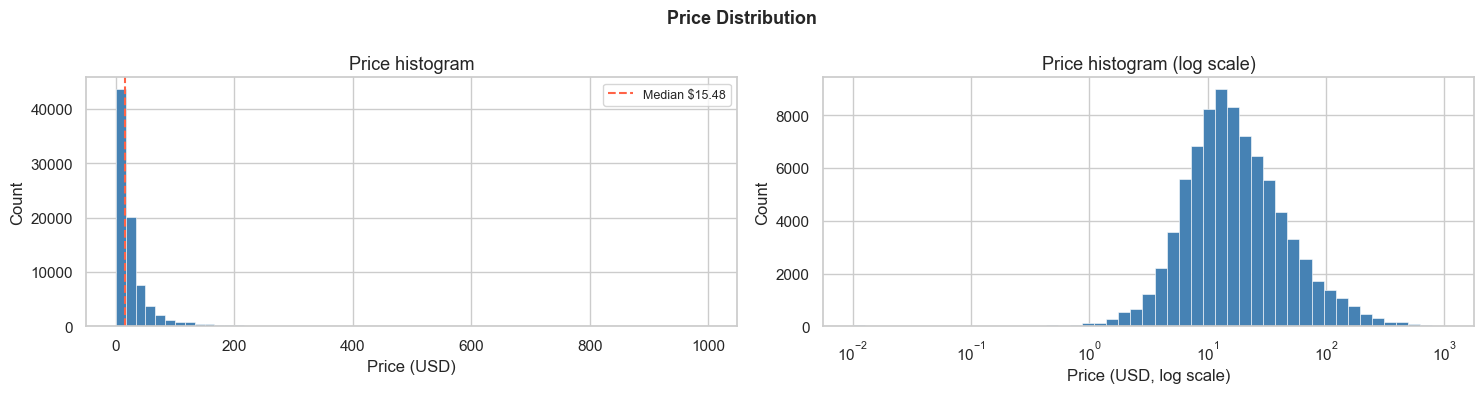

Price range: $0.01 – $998.99
Mean: $29.83  |  Median: $15.48  |  Std: $49.31
Top 5 most expensive items:
      asin                                                                                 title  price
B00I2RVFBQ Aquatic Life 46-Inch XS-UV Reef with 246-watt LED Professional Aquarium Light Fixture 998.99
B00F3FKH9Q                                       Galvanized Steel Multiple Dog Kennel for 2 Dogs 995.26
B0012IWNL8                                       HydroSurge Bath Pro 5-1 Bathing System by Oster 995.00
B00GOC9RTS                                   Solo Pet Door Automatic Electronic Dog and Cat Door 995.00
B00E3T0T46          Lucky Dog European Style Modular Kennel with Predator Top, 6 by 5 by 10-Feet 979.66


In [17]:
# TODO: explore potential outliers?

price_clean = meta_df['price'].dropna()

Q1, Q3 = price_clean.quantile(0.25), price_clean.quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Histogram (log x-axis to handle skew)
axes[0].hist(price_clean[price_clean > 0], bins=60, color='steelblue',
             edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Count')
axes[0].set_title('Price histogram')
axes[0].axvline(price_clean.median(), color='tomato', linestyle='--',
                label=f'Median ${price_clean.median():.2f}')
axes[0].legend(fontsize=9)

# Log-scale histogram
axes[1].hist(price_clean[price_clean > 0], bins=np.logspace(
    np.log10(price_clean[price_clean > 0].min()),
    np.log10(price_clean.max()), 50),
    color='steelblue', edgecolor='white', linewidth=0.4)
axes[1].set_xscale('log')
axes[1].set_xlabel('Price (USD, log scale)')
axes[1].set_ylabel('Count')
axes[1].set_title('Price histogram (log scale)')

plt.suptitle('Price Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Price range: ${price_clean.min():.2f} – ${price_clean.max():.2f}")
print(f"Mean: ${price_clean.mean():.2f}  |  Median: ${price_clean.median():.2f}  |  Std: ${price_clean.std():.2f}")
print(f"Top 5 most expensive items:")
print(meta_df.nlargest(5, 'price')[['asin', 'title', 'price']].to_string(index=False))

#### Observation
The price distribution is highly skewed, with a long tail of expensive items. The majority of products are priced under $50, but there are some outliers that cost several hundred dollars. The mean price is around $30, while the median is closer to $15, a consequence of those few, highly priced items. Might be worth it to perform log-transformation or to cap prices for modeling?

In [18]:
# TODO: analyze sales rank?

### Product categories

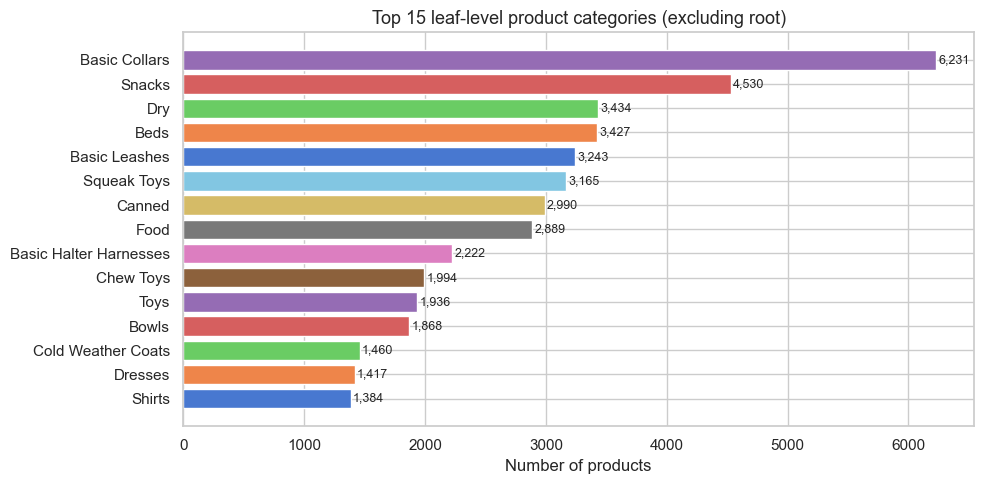

In [19]:
def flatten_categories(cat_val):
    """Return a flat list of all leaf-level category strings."""
    if cat_val is None:
        return []
    if isinstance(cat_val, float) and np.isnan(cat_val):
        return []
    try:
        nested = ast.literal_eval(cat_val) if isinstance(cat_val, str) else cat_val
        if not isinstance(nested, list):
            return []
        return [path[-1] for path in nested if isinstance(path, list) and path]
    except Exception:
        return []

all_cats = [cat for cats in meta_df['categories'].apply(flatten_categories) for cat in cats]
cat_counts = Counter(all_cats)
# Exclude the generic root
for key in ['Pet Supplies', 'Pet Supplies: International Shipping Available']:
    cat_counts.pop(key, None)

top_cats = pd.DataFrame(cat_counts.most_common(15), columns=['category', 'count'])

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_cats['category'][::-1], top_cats['count'][::-1],
               color=sns.color_palette('muted', 15))
ax.set_xlabel('Number of products')
ax.set_title('Top 15 leaf-level product categories (excluding root)', fontsize=13)
for bar, val in zip(bars, top_cats['count'][::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Price and avg rating correlation

In [20]:
# TODO: if we do sales rank analysis, move this to the corresponding section (above)
# Extract numeric sales rank for 'Pet Supplies' category
def extract_pet_rank(rank_val):
    """Parse salesRank dict and return the Pet Supplies rank as an integer."""
    if pd.isna(rank_val):
        return np.nan
    try:
        if isinstance(rank_val, str):
            d = ast.literal_eval(rank_val)
        else:
            d = rank_val
        return int(d.get('Pet Supplies', np.nan))
    except Exception:
        return np.nan
    
meta_df['sales_rank_numeric'] = meta_df['salesRank'].apply(extract_pet_rank)
rank_clean = meta_df['sales_rank_numeric'].dropna()

Items with both ratings and price data: 75,924


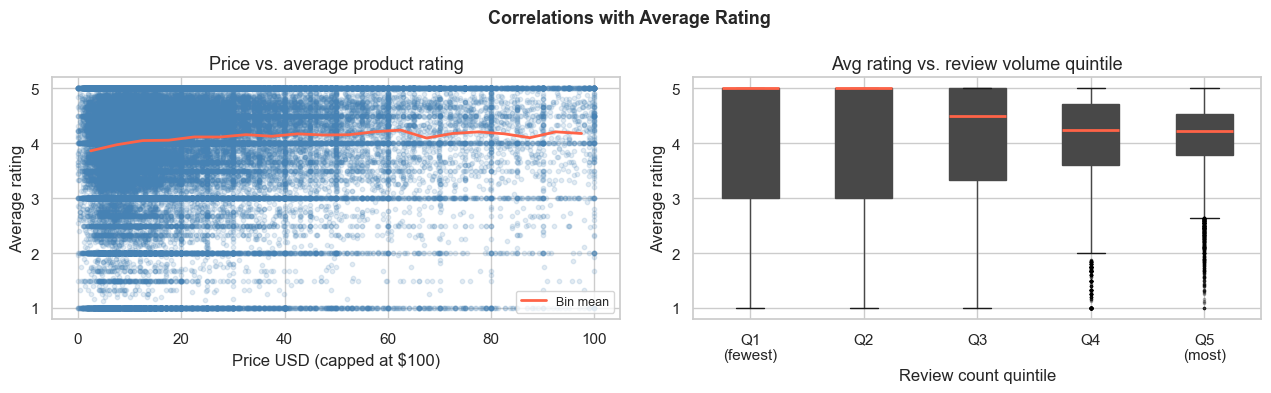

Pearson correlation — price vs avg_rating    : +0.0294
Pearson correlation — review_count vs avg_rating: +0.0115


In [21]:
# Aggregate ratings by item
item_stats = ratings_df.groupby('asin').agg(
    avg_rating=('rating', 'mean'),
    review_count=('rating', 'count')
).reset_index()

# Merge with metadata on asin
# Note: ratings_df asin is stored as str; meta_df asin is also str
merged = item_stats.merge(meta_df[['asin', 'price', 'sales_rank_numeric']], on='asin', how='inner')
merged_priced = merged.dropna(subset=['price'])

print(f"Items with both ratings and price data: {len(merged_priced):,}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scatter: price vs avg rating (capped at 95th percentile for readability)
price_cap = merged_priced['price'].quantile(0.95)
plot_data = merged_priced[merged_priced['price'] <= price_cap].copy()

axes[0].scatter(plot_data['price'], plot_data['avg_rating'],
                alpha=0.15, s=10, color='steelblue')
# Bin means for trend line
plot_data['price_bin'] = pd.cut(plot_data['price'], bins=20)
bin_means = plot_data.groupby('price_bin', observed=True)['avg_rating'].mean()
bin_centers = [interval.mid for interval in bin_means.index]
axes[0].plot(bin_centers, bin_means.values, color='tomato', linewidth=2, label='Bin mean')
axes[0].set_xlabel(f'Price USD (capped at ${price_cap:.0f})')
axes[0].set_ylabel('Average rating')
axes[0].set_title('Price vs. average product rating')
axes[0].legend(fontsize=9)

# Box plot: avg rating grouped by rating quintile of review_count
merged['review_quintile'] = pd.qcut(
    merged['review_count'].rank(method='first'),
    5,
    labels=['Q1\n(fewest)', 'Q2', 'Q3', 'Q4', 'Q5\n(most)']
)
merged.boxplot(column='avg_rating', by='review_quintile', ax=axes[1],
               patch_artist=True, medianprops=dict(color='tomato', linewidth=2),
               flierprops=dict(marker='.', alpha=0.3, markersize=3))
axes[1].set_xlabel('Review count quintile')
axes[1].set_ylabel('Average rating')
axes[1].set_title('Avg rating vs. review volume quintile')
plt.suptitle('')

plt.suptitle('Correlations with Average Rating', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

corr_price = merged_priced['price'].corr(merged_priced['avg_rating'])
corr_count = merged['review_count'].corr(merged['avg_rating'])
print(f"Pearson correlation — price vs avg_rating    : {corr_price:+.4f}")
print(f"Pearson correlation — review_count vs avg_rating: {corr_count:+.4f}")

#### Observation
There doesnt seem to be a strong correlation between price and average rating. Items with more reviews tend towards the overall mean rating (4.11), while items with fewer reviews show more variability. The most popular items (in the Q5 quintile by review count) are reliable rated around 4.

### Top brands by review count

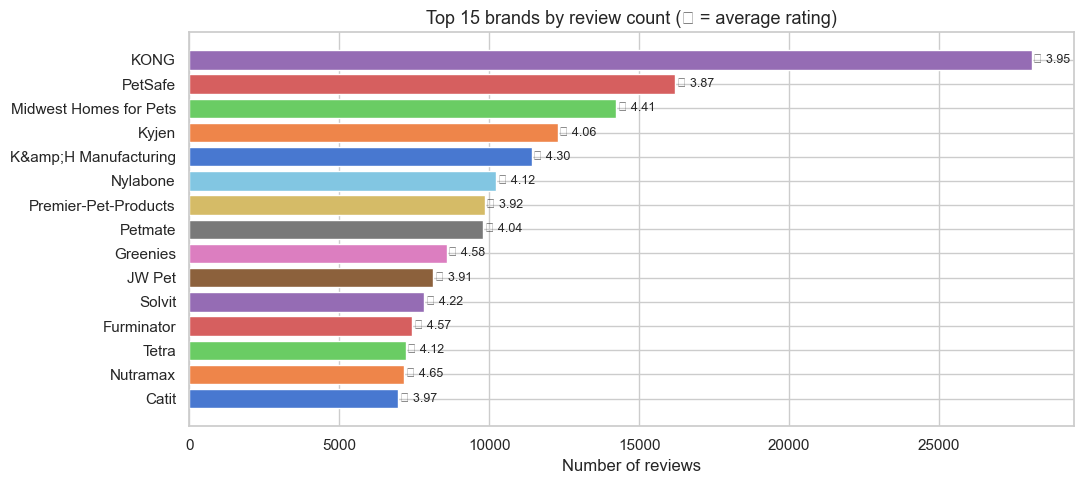

In [22]:
# Clean brand: treat empty string as NaN
meta_df['brand_clean'] = meta_df['brand'].replace('', np.nan)

brand_items = meta_df.dropna(subset=['brand_clean']).groupby('brand_clean')['asin'].apply(list)

# Map each asin to its brand
asin_to_brand = meta_df.dropna(subset=['brand_clean']).set_index('asin')['brand_clean'].to_dict()
ratings_df['brand'] = ratings_df['asin'].map(asin_to_brand)

top_brands_reviews = (
    ratings_df.dropna(subset=['brand'])
    .groupby('brand')
    .agg(review_count=('rating', 'count'), avg_rating=('rating', 'mean'))
    .nlargest(15, 'review_count')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(top_brands_reviews['brand'][::-1],
               top_brands_reviews['review_count'][::-1],
               color=sns.color_palette('muted', 15))
# Overlay average rating as text
for bar, (_, row) in zip(bars, top_brands_reviews[::-1].iterrows()):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'★ {row["avg_rating"]:.2f}', va='center', fontsize=9)
ax.set_xlabel('Number of reviews')
ax.set_title('Top 15 brands by review count (★ = average rating)', fontsize=13)
plt.tight_layout()
plt.show()

In [23]:
# print also the 5 less popular brands by review count (with at least 10 reviews to avoid noise)
least_popular = (
    ratings_df.dropna(subset=['brand'])
    .groupby('brand')
    .agg(review_count=('rating', 'count'), avg_rating=('rating', 'mean'))
    .query('review_count >= 10')
    .nsmallest(5, 'review_count')
    .reset_index()
)
print("5 least popular brands (with at least 10 reviews):")
print(least_popular.to_string(index=False))

5 least popular brands (with at least 10 reviews):
                                 brand  review_count  avg_rating
                 3 Green Dogs Vitamins            10         5.0
                   8 in 1 Pet Products            10         3.7
              ABO Gear Aussie Naturals            10         3.6
ANTI ICKY POO - STAIN REMOVER - P-BATH            10         4.3
                             Abco Tech            10         2.3


#### Observation
KONG is the most popular brand by review count, followed by PetSafe and Midwest Homes for Pets. The more reviews for a particular brand, the more accurate the assesment of the quality of their products becomes. So while less popular brands like '3 Green Dogs Vitamins' have higher average ratings, we should be cautious in interpreting those as they are based on fewer reviews.

# Pre-processing

## Metadata

### Ratings timestamp conversion

In [24]:
ratings_df['date'] = pd.to_datetime(ratings_df['timestamp'], unit='s')
ratings_df['year']  = ratings_df['date'].dt.year
ratings_df['month'] = ratings_df['date'].dt.month

print("Ratings dataframe after timestamp conversion:")
ratings_df[['user_id', 'asin', 'rating', 'timestamp', 'date', 'year', 'month']].head()

Ratings dataframe after timestamp conversion:


,user_id,asin,rating,timestamp,date,year,month
0,A3PG0KS1YE8MR4,0615553605,5.0,1354838400,2012-12-07,2012,12
1,A363P047LR5XI6,0615553605,4.0,1373932800,2013-07-16,2013,7
2,ABZ8CQXD42H4,0615553605,1.0,1386028800,2013-12-03,2013,12
3,A3J8QW1MV1OP01,0615583474,5.0,1347321600,2012-09-11,2012,9
4,A3ISA8Z0NB0ILH,0615583474,5.0,1358899200,2013-01-23,2013,1


### Add sales rank to metadata dataset

In [25]:
# sales_rank_numeric was already created during exploration; confirm it exists
if 'sales_rank_numeric' not in meta_df.columns:
    meta_df['sales_rank_numeric'] = meta_df['salesRank'].apply(extract_pet_rank)

print(f"sales_rank_numeric — non-null: {meta_df['sales_rank_numeric'].notna().sum():,} / {len(meta_df):,}")
print(meta_df['sales_rank_numeric'].describe())

sales_rank_numeric — non-null: 103,590 / 110,707
count    103590.000000
mean     128851.501670
std      111962.406331
min           1.000000
25%       39576.250000
50%       99755.500000
75%      185744.250000
max      512802.000000
Name: sales_rank_numeric, dtype: float64


### Handle missing values

In [26]:
# Work on a copy to preserve the raw frame
meta_clean = meta_df.copy()

# ── brand ─────────────────────────────────────────────────────────────────────
# Replace empty strings and NaN with 'Unknown'
meta_clean['brand'] = meta_clean['brand'].replace('', np.nan).fillna('Unknown')

# ── price ─────────────────────────────────────────────────────────────────────
# Fill missing prices with the median (more robust than mean given the skewed distribution)
# TODO: could also consider dropping these entries entirely if we think price is a critical feature
price_median = meta_clean['price'].median()
meta_clean['price_filled'] = meta_clean['price'].fillna(price_median)
# Also create a flag so models can distinguish imputed from observed
meta_clean['price_was_missing'] = meta_clean['price'].isna().astype(int)
print(f"Price median used for imputation: ${price_median:.2f}")

# ── sales_rank_numeric ────────────────────────────────────────────────────────
# Fill with median rank (neutral assumption: average popularity)
# TODO: like with price, consider dropping if rank ends up being critical
rank_median = meta_clean['sales_rank_numeric'].median()
meta_clean['sales_rank_filled'] = meta_clean['sales_rank_numeric'].fillna(rank_median)
meta_clean['rank_was_missing'] = meta_clean['sales_rank_numeric'].isna().astype(int)
print(f"Sales rank median used for imputation: {int(rank_median):,}")

# ── description ──────────────────────────────────────────────────────────────
# Fill with empty string
meta_clean['description'] = meta_clean['description'].fillna('')

# ── title ────────────────────────────────────────────────────────────────────
# Very few missing (< 0.2%); fill with 'Unknown'
meta_clean['title'] = meta_clean['title'].fillna('Unknown')

# ── related ──────────────────────────────────────────────────────────────────
# Replace NaN with empty dict (no co-purchase links available)
meta_clean['related'] = meta_clean['related'].apply(
    lambda x: {} if pd.isna(x) or x != x else x
)

# Confirm no remaining NaN in key columns
print("\nRemaining nulls after cleaning:")
remaining = meta_clean[['brand', 'price_filled', 'sales_rank_filled', 'description', 'title']].isnull().sum()
print(remaining)

assert meta_clean['brand'].isnull().sum() == 0, "Nulls remain in 'brand'"
assert meta_clean['price_filled'].isnull().sum() == 0, "Nulls remain in 'price_filled'"
assert meta_clean['sales_rank_filled'].isnull().sum() == 0, "Nulls remain in 'sales_rank_filled'"
assert meta_clean['description'].isnull().sum() == 0, "Nulls remain in 'description'"

Price median used for imputation: $15.48
Sales rank median used for imputation: 99,755

Remaining nulls after cleaning:
brand                0
price_filled         0
sales_rank_filled    0
description          0
title                0
dtype: int64


### Log transformation of price and sales rank

Why do this? Both price and sales rank are highly skewed, with a long tail of expensive items and low-ranked products. Log-transforming these features can help to reduce the skewness and make the data more normally distributed, which can help imporove the performance of our models. Plus it mitigates the influence of outliers.

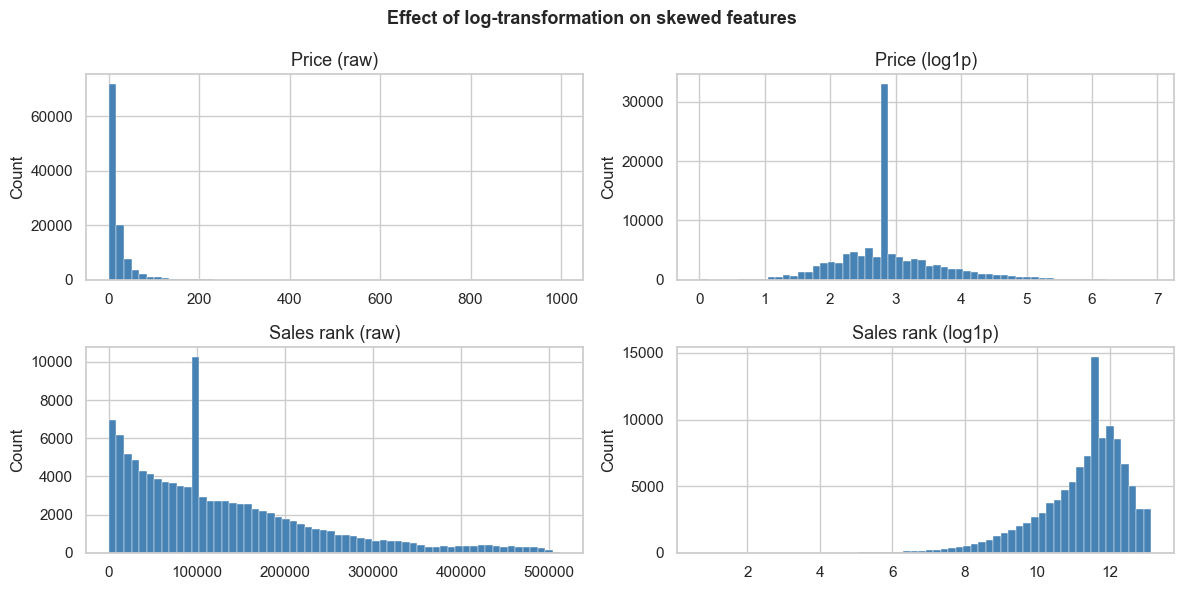

In [27]:
# Log1p handles zeros cleanly
meta_clean['log_price']      = np.log1p(meta_clean['price_filled'])
meta_clean['log_sales_rank'] = np.log1p(meta_clean['sales_rank_filled'])

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, col, title in zip(
    axes.flat,
    ['price_filled', 'log_price', 'sales_rank_filled', 'log_sales_rank'],
    ['Price (raw)', 'Price (log1p)', 'Sales rank (raw)', 'Sales rank (log1p)']
):
    data = meta_clean[col].dropna()
    ax.hist(data, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_title(title)
    ax.set_ylabel('Count')

plt.suptitle('Effect of log-transformation on skewed features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Merge datasets

We combine the ratings and pre-processed metadata datasets into a single dataframe that contains all the relevant information for each review.

In [28]:
# Aggregate ratings to one row per item
item_agg = ratings_df.groupby('asin').agg(
    avg_rating=('rating', 'mean'),
    rating_count=('rating', 'count'),
    rating_std=('rating', 'std'),
    first_review_date=('date', 'min'),
    last_review_date=('date', 'max')
).reset_index()

# Select the cleaned metadata columns needed for modelling
meta_cols = ['asin', 'title', 'brand', 'price_filled', 'log_price',
             'sales_rank_filled', 'log_sales_rank',
             'price_was_missing', 'rank_was_missing']

item_df = item_agg.merge(meta_clean[meta_cols], on='asin', how='left')

print(f"Item-level table shape: {item_df.shape}")
print(f"Items with metadata match: {item_df['title'].notna().sum():,} / {len(item_df):,}")
item_df.head(10)

Item-level table shape: (103288, 14)
Items with metadata match: 103,288 / 103,288


,asin,avg_rating,rating_count,rating_std,first_review_date,last_review_date,title,brand,price_filled,log_price,sales_rank_filled,log_sales_rank,price_was_missing,rank_was_missing
0,0615553605,3.333333,3,2.081666,2012-12-07,2013-12-03,Pet Qwerks Treat Cookbook with Cutters,Pet Qwerks,10.95,2.480731,34134.0,10.438079,0,0
1,0615583474,5.000000,8,0.000000,2012-09-11,2013-06-18,It's A Cat's Life,Unknown,15.48,2.802148,452691.0,13.022967,1,0
2,0972585419,3.130435,23,1.516705,2007-02-20,2014-04-26,Feathered Phonics The Easy Way To Teach Your B...,Pet Media,0.92,0.652325,21104.0,9.957265,0,0
3,0975412809,4.641509,53,0.900733,2006-03-29,2014-07-14,Notes From The Grooming Table by Melissa Verplank,Melissa Verplank,59.95,4.110054,1960.0,7.581210,0,0
4,0975412868,3.857143,7,1.676163,2011-05-25,2013-03-12,Theory of Five Book by Melissa Verplank,Unknown,15.48,2.802148,70355.0,11.161323,1,0
5,0977264815,5.000000,1,NaN,2007-03-28,2007-03-28,ABC's of Behavior Shaping; Proactive Behavior ...,Unknown,15.48,2.802148,206215.0,12.236679,1,0
6,0979137802,5.000000,1,NaN,2013-04-17,2013-04-17,Antique Christmas Memories,Unknown,15.48,2.802148,399005.0,12.896732,1,0
7,0979699967,3.000000,2,1.414214,2014-02-20,2014-06-15,Simply Charming Circles,Unknown,1.45,0.896088,157918.0,11.969838,0,0
8,0982393555,3.000000,4,2.309401,2012-06-12,2013-11-24,Pill Wrap Paste - 56 servings,Unknown,15.48,2.802148,132242.0,11.792396,1,0
9,0983794804,4.750000,4,0.500000,2012-05-30,2013-05-02,"Pathway Dog Journal, Capture Your Memories, Pe...",Unknown,25.97,3.294725,62710.0,11.046292,0,0
